In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00a 0:00:01


In [4]:
from ultralytics import YOLO
import os

In [7]:
DATA_PATH = "/kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset"

print(os.listdir(DATA_PATH))

['data.yaml', 'val', 'test', 'train']


In [8]:
import yaml

yaml_path = "/kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = "/kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset"

with open("data_fixed.yaml", 'w') as f:
    yaml.dump(data, f)

print("✅ YAML fixed and saved as data_fixed.yaml")

✅ YAML fixed and saved as data_fixed.yaml


In [9]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU: Tesla T4


In [10]:
print(os.listdir(DATA_PATH))
print(os.listdir(f"{DATA_PATH}/train"))
print(os.listdir(f"{DATA_PATH}/train/images")[:5])

['data.yaml', 'val', 'test', 'train']
['labels', 'images']
['underwater_dataset_17449.jpg', 'underwater_dataset_17949.jpg', 'brackish_dataset_13618.jpg', 'brackish_dataset_5922.jpg', 'brackish_dataset_10690.jpg']


In [12]:
model = YOLO("yolov8m.pt")   #  best balance (accuracy + speed)

YAML_PATH="/kaggle/working/data_fixed.yaml"

In [13]:
results = model.train(
    data=YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,

    # 🔥 optimization
    lr0=0.01,
    lrf=0.01,

    # 🔥 regularization
    weight_decay=0.0005,

    # 🔥 augmentation (YOLO built-in)
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,

    flipud=0.0,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.2,

    # 🔥 stability
    patience=15,

    # 🔥 performance
    workers=4,
    device=0,

    # logging
    name="fish_detector_v1"
)

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fish_detector_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, per

In [14]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 63.5±39.3 MB/s, size: 32.7 KB)
val: Scanning /kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset/val/labels... 1971 images, 229 backgrounds, 1330 corrupt: 100% ━━━━━━━━━━━━ 1971/1971 786.8it/s 2.5s0.1s
val: /kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset/val/images/aquarium_dataset_514.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset/val/images/aquarium_dataset_515.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/process

In [15]:


results = model.predict(
    source=f"{DATA_PATH}/test/images",
    conf=0.4,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2043 /kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset/test/images/aquarium_dataset_0.jpg: 640x480 1 fish, 46.8ms
image 2/2043 /kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset/test/images/aquarium_dataset_1.jpg: 640x480 3 fishs, 27.4ms
image 3/2043 /kaggle/input/datasets/satyamsingh0912/fish-detection-dataset/processed_detector_dataset/test/images/aquarium_dataset_10.j

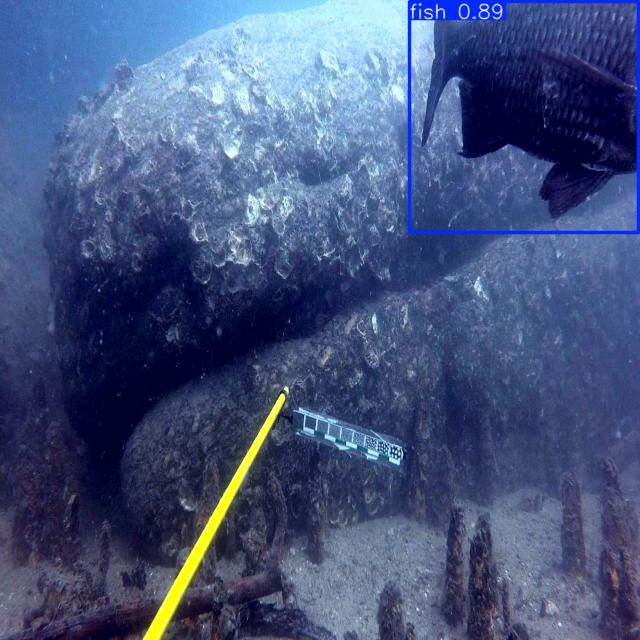

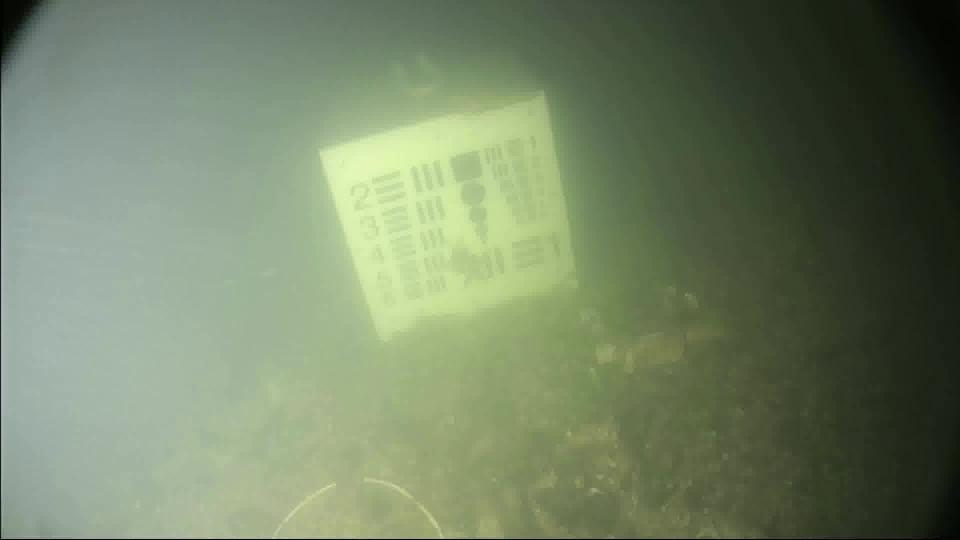

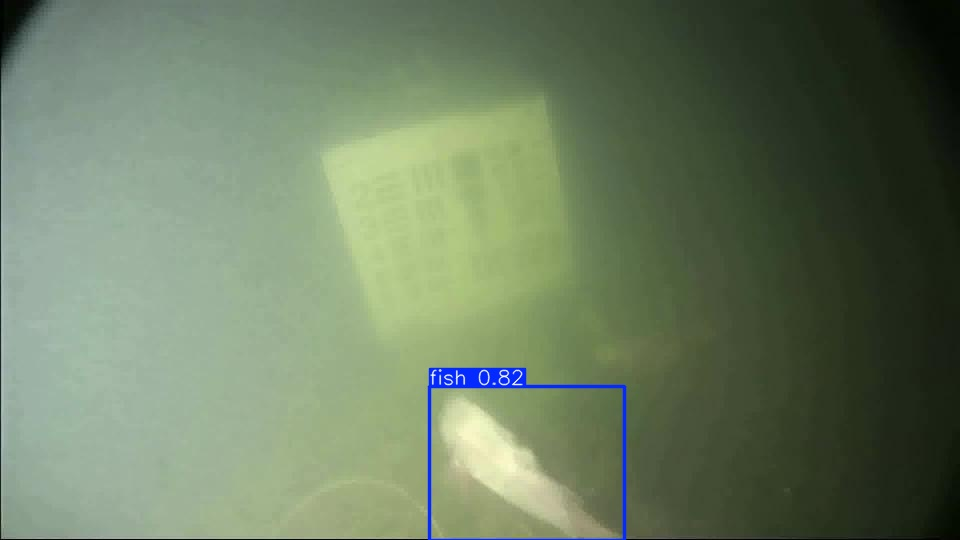

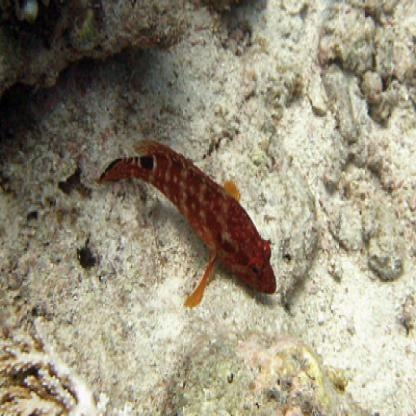

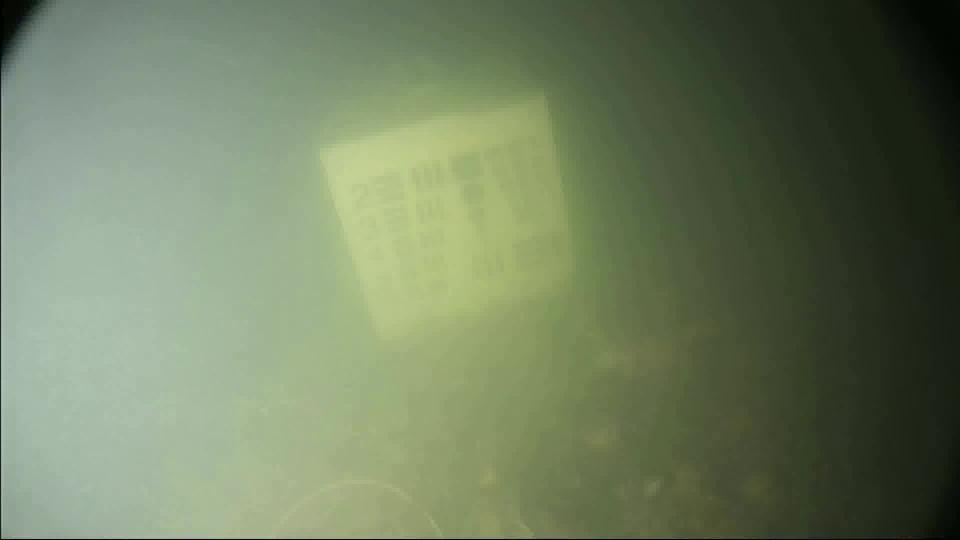

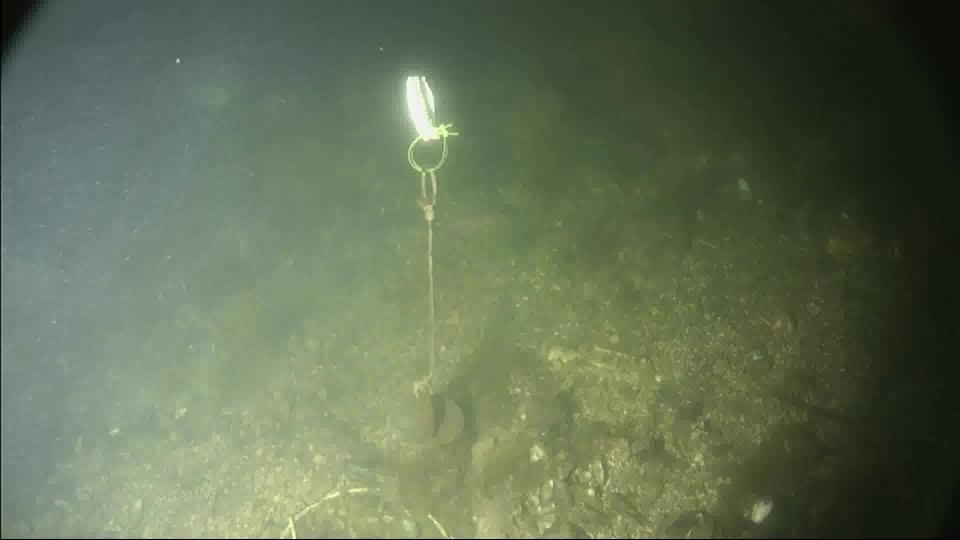

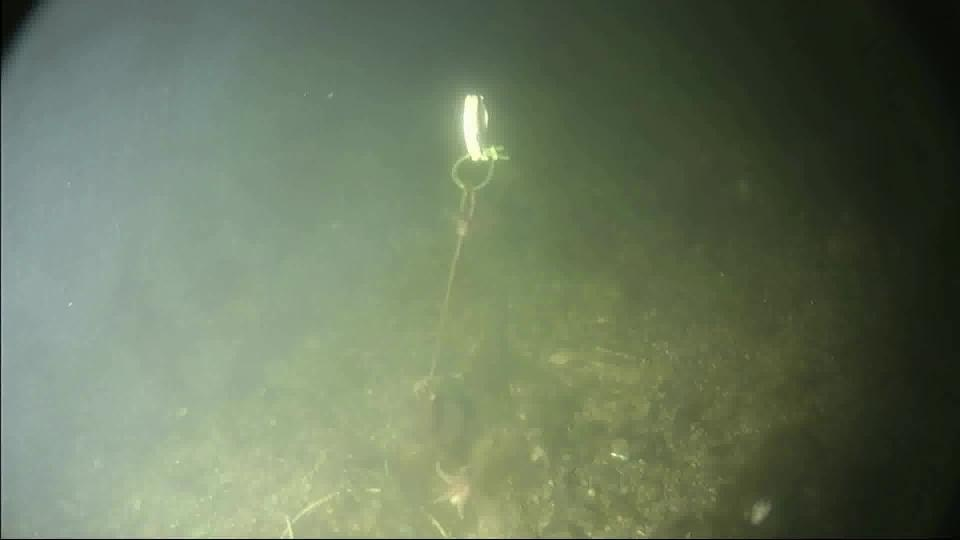

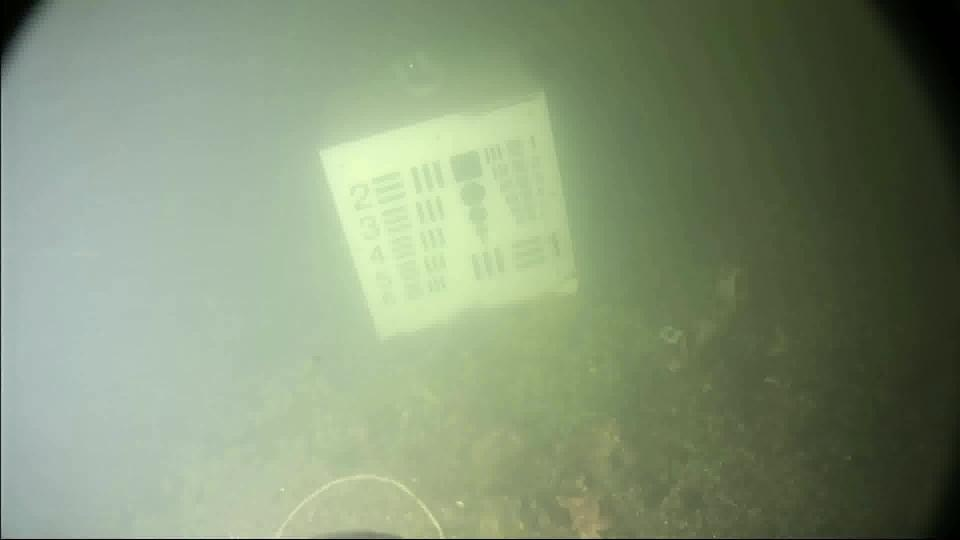

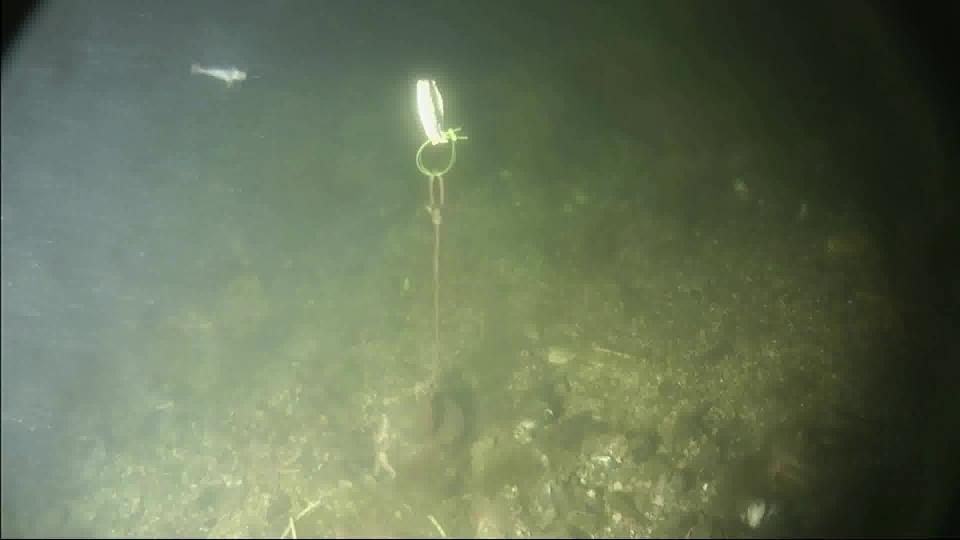

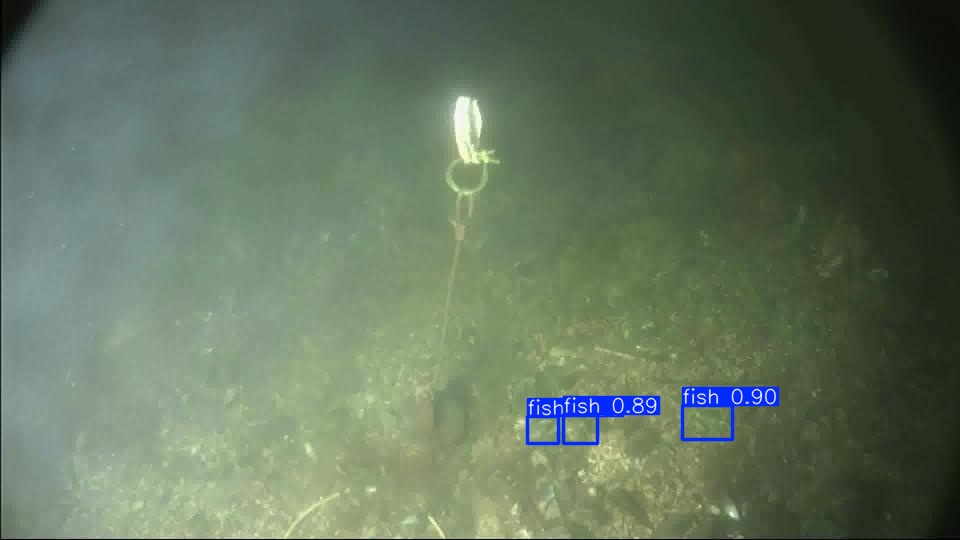

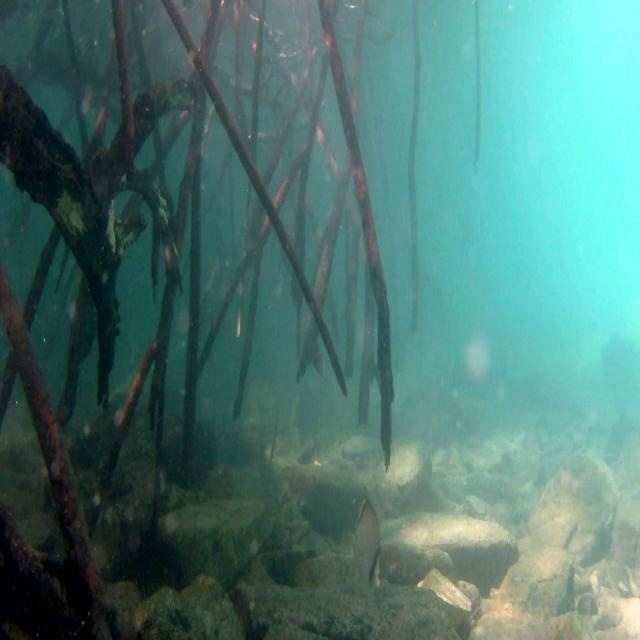

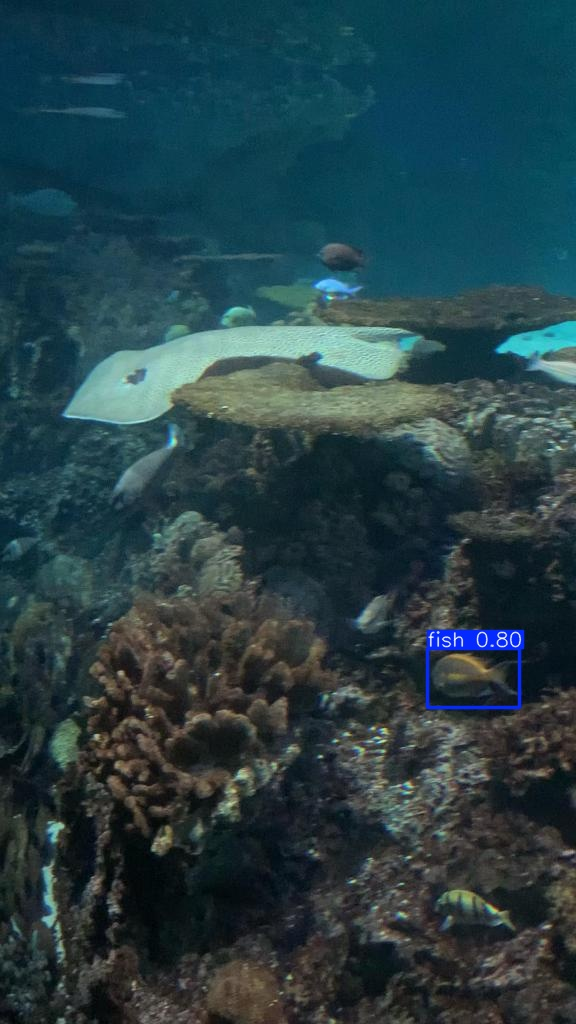

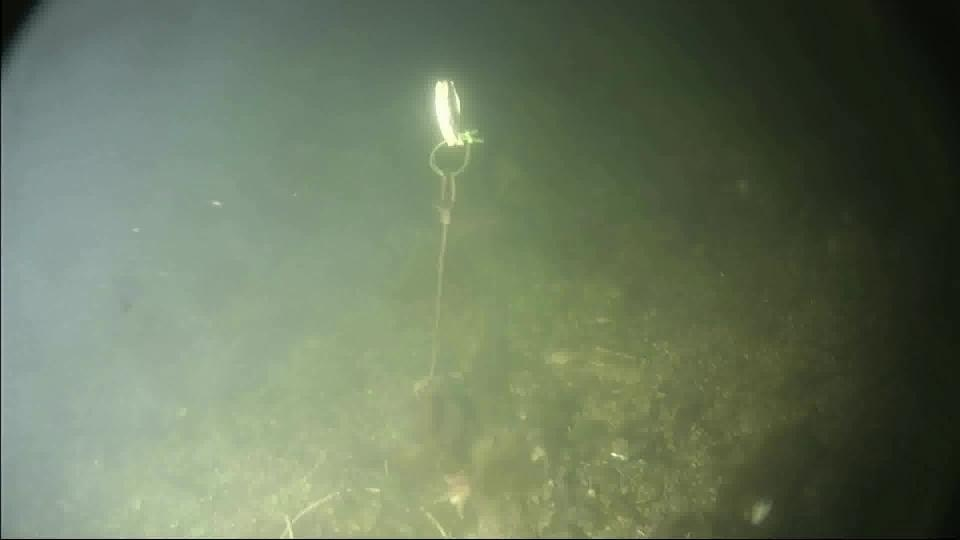

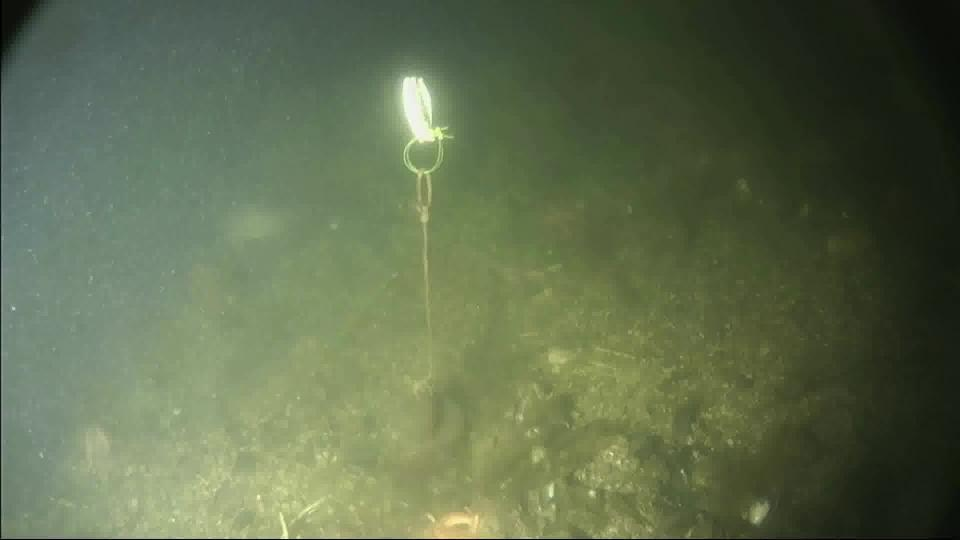

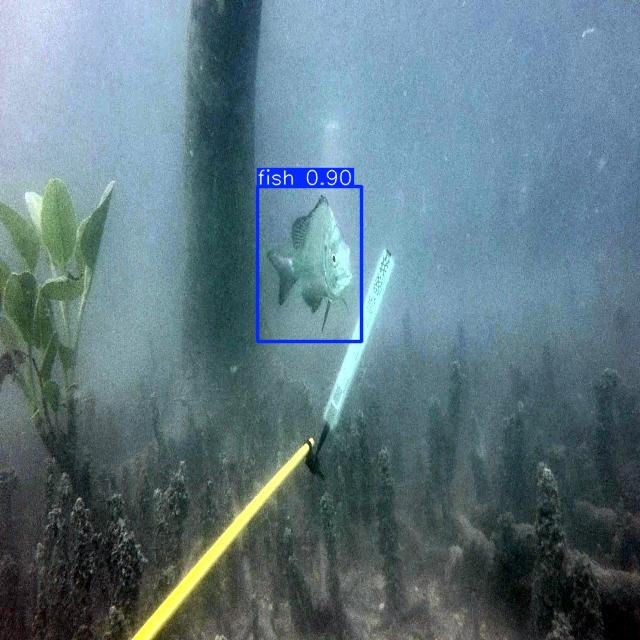

In [17]:
from IPython.display import Image, display
import glob

preds = glob.glob("/kaggle/working/runs/detect/predict/*.jpg")

for img in preds[:15]:
    display(Image(filename=img))

In [ ]:
import shutil

shutil.make_archive(
    "fish_detector_model",
    'zip',
    "/kaggle/working/runs/detect/fish_detector_v1"
)

In [24]:
!pip install -q PyDrive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 14.6 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


In [25]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [31]:
file = drive.CreateFile({'title': 'best_model.pt'})
file.SetContentFile('/kaggle/working/fish_detector.pt')
file.Upload()

print("Uploaded to Drive!")

Uploaded to Drive!


In [29]:
import shutil

shutil.copy(
    "/kaggle/working/runs/detect/fish_detector_v1/weights/best.pt",
    "/kaggle/working/fish_detector.pt"
)

'/kaggle/working/fish_detector.pt'

In [30]:
import os
print(os.listdir("/kaggle/working"))

['yolov8m.pt', 'best_model.bin', 'yolo26n.pt', 'download', 'model.zip', 'runs', 'fish_detector_model.zip', 'data_fixed.yaml', 'full_project.zip', '.virtual_documents', 'fish_detector.pt', 'best.pt']
